# Tier 13: electric machines sized by torque, speed and gear ratio as design variables

The external review said machine mass was just power divided by a constant,
so the model couldn't trade direct against geared drive, or gear ratio and
speed. Now:

- **Machine mass:** smooth maximum of peak torque / torque density and rated
  power / specific-power cap (`TorqueDensityMassModel`).
  - Torque density 15 N.m/kg: magniX magni650, 3,216 N.m in 206 kg with
    inverters and cables.
  - Cap 10 kW/kg at high speed.
- **Rotor gearbox:** AFDD00 (NDARC), with a mild ratio penalty.
- **Generator:** either on the engine's 1,210 rpm output shaft (the engine
  as delivered by the OEM) or through a step-up gearbox.
- **Design variables:** motor speed, rotor gear ratio and generator speed.

The user also asked for motor, generator and turbine power to be sized
distinctly; they are reported separately below and drawn with distinct
line styles on the dashboard's constraint diagram.

```powershell
uv run jupyter lab notebooks/tier13_machines
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.motor import Motor, TorqueDensityMassModel, rubber_machine
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_tier12b, requirements_tier12b,
                                  solve_halo_sizing)

# Tier 13 record: without the Tier 16 hot-day hover.
R13 = requirements_tier12b

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

# Plan 022 made the 780 kg equivalent-circuit pack the reference; this notebook keeps reproducing its own tier
# (900 kg, constant-OCV battery).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, HaloRequirements as _HaloRequirements
from examples.halo_sizing import solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          battery_model="constant", wing_weight_model="raymer",
                          aerodynamics_model="simple", thermal_model=False)
HaloRequirements = partial(_HaloRequirements, mass_payload_kg=900.0)
solve_halo_sizing = partial(_solve_halo_sizing, requirements=HaloRequirements(), assumptions=HaloAssumptions())


## 1. Machine mass against speed at fixed power

At fixed power, torque falls as 1/speed, so a torque-sized machine gets
lighter as it spins faster, until the specific-power cap takes over. The
specific-power model (Tiers 1–12b) is flat.

PASS  torque-sized mass falls with speed, then flattens at the specific-power cap


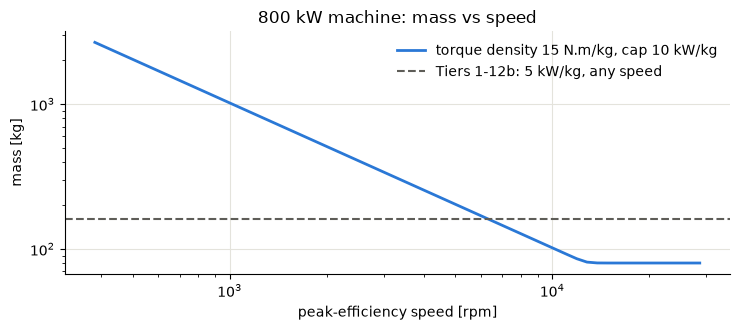

In [2]:
power_W = 800e3
speeds = np.geomspace(40, 3000, 60)
model = TorqueDensityMassModel()
torque_mass = [float(rubber_machine(Motor, w, power_W / (1.25 * w), torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5,
                                    mass_model=model).get_mass()) for w in speeds]
flat = power_W / 5000.0
check("torque-sized mass falls with speed, then flattens at the specific-power cap",
      torque_mass[0] > 10 * torque_mass[-1] and abs(torque_mass[-1] - power_W / 10000.0) < 3)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.loglog(speeds * 60 / (2 * np.pi), torque_mass, color=blue, lw=2, label="torque density 15 N.m/kg, cap 10 kW/kg")
ax.axhline(flat, color=ink_muted, lw=1.5, ls="--", label="Tiers 1-12b: 5 kW/kg, any speed")
ax.set(xlabel="peak-efficiency speed [rpm]", ylabel="mass [kg]", title="800 kW machine: mass vs speed")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 2. Architectures: geared vs direct drive, generator step-up vs on-shaft

Payload is maximized at the 210 kt reference, around the fixed
2 x 1,120 hp engines. The engine as delivered turns its output shaft at
1,210 rpm.

In [3]:
cases = {
    "Tier 12b: specific-power machines": dict(assumptions=assumptions_tier12b),
    "Tier 13: geared rotors, step-up generators": {},
    "Tier 13: generators on the 1,210 rpm shaft": dict(assumptions=replace(HaloAssumptions(), generator_step_up=False)),
}
results = {}
for label, kwargs in cases.items():
    results[label] = solve_halo_sizing(requirements=R13, objective="payload", **kwargs)
    pt = dict(results[label].powertrain_masses_kg)
    print(f"{label:<44} max payload {results[label].mass_payload_kg:6.0f} kg | motors {pt['motor']:5.0f} kg, gearboxes "
          f"{pt['gearbox']:5.0f} kg, generators {pt['generator']:5.0f} kg, step-up {pt.get('generator_gearbox', 0):4.0f} kg")
try:
    solve_halo_sizing(requirements=R13, objective="payload", assumptions=replace(HaloAssumptions(), direct_drive_rotor=True))
    direct_feasible = True
except RuntimeError:
    direct_feasible = False
radius_m, tip_m_s = 4.4, 238.0
hover_motor_W = 811e3
peak_torque_Nm = 2.5 * hover_motor_W / (1.25 * tip_m_s / radius_m)
print(f"direct drive: no feasible design found; each motor would need ~{peak_torque_Nm / 1e3:.0f} kN.m peak "
      f"(~{peak_torque_Nm / 15 / 1e3:.1f} t at 15 N.m/kg)")
geared = results["Tier 13: geared rotors, step-up generators"].mass_payload_kg
check("torque-sized geared design carries more than the specific-power baseline",
      geared > results["Tier 12b: specific-power machines"].mass_payload_kg)
check("generators on the engine's 1,210 rpm shaft lose most of the payload",
      results["Tier 13: generators on the 1,210 rpm shaft"].mass_payload_kg < 0.25 * geared)
check("direct-drive rotors are infeasible (motor torque mass)", not direct_feasible)

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


Tier 12b: specific-power machines            max payload    935 kg | motors   353 kg, gearboxes   400 kg, generators   354 kg, step-up    0 kg


Tier 13: geared rotors, step-up generators   max payload   1014 kg | motors   159 kg, gearboxes   373 kg, generators   163 kg, step-up  175 kg


Tier 13: generators on the 1,210 rpm shaft   max payload     33 kg | motors   170 kg, gearboxes   400 kg, generators  1464 kg, step-up    0 kg


direct drive: no feasible design found; each motor would need ~30 kN.m peak (~2.0 t at 15 N.m/kg)
PASS  torque-sized geared design carries more than the specific-power baseline
PASS  generators on the engine's 1,210 rpm shaft lose most of the payload
PASS  direct-drive rotors are infeasible (motor torque mass)


## 3. Reference: 900 kg at 210 kt, with motor, generator and turbine sized distinctly

In [4]:
r = solve_halo_sizing(requirements=R13)
d = r.design
base = solve_halo_sizing(requirements=R13, assumptions=assumptions_tier12b)
print(f"take-off {r.mass_takeoff_kg / u.lbm:,.0f} lb (Tier 12b: {base.mass_takeoff_kg / u.lbm:,.0f} lb)")
print(f"rotor gear ratio {d.reduction_ratio:.1f}; motor peak-efficiency speed {d.speed_peak_motor_rad_s * 60 / (2 * np.pi):,.0f} rpm; "
      f"generator {d.speed_peak_generator_rad_s * 60 / (2 * np.pi):,.0f} rpm (engine output 1,210 rpm)")
print(f"motors 2 x {r.power_rated_motor_W / 1e3:,.0f} kW | generators 2 x {r.power_rated_generator_W / 1e3:,.0f} kW | "
      f"turbines 2 x {d.power_rated_turboshaft_W / u.hp:,.0f} hp ({d.power_rated_turboshaft_W / 1e3:,.0f} kW)")
check("Tier 12b reference still reproduces 14,877 lb", abs(base.mass_takeoff_kg / u.lbm - 14877) < 5)
check("torque sizing lowers take-off weight", r.mass_takeoff_kg < base.mass_takeoff_kg)
check("every constraint satisfied", r.min_margin > -1e-6)
segs = {s["label"]: s for s in r.segments}
torque = {k: s["torque_motor_Nm"] for k, s in segs.items()}
print("motor torque by segment [N.m]:", {k: round(v) for k, v in torque.items()})
peak_segment = max(torque, key=torque.get)
print(f"peak motor torque set by: {peak_segment}")
check("torque trap found: a slow-rotor airplane-mode segment (climb), not hover, sets peak motor torque",
      peak_segment == "climb" and torque["climb"] > torque["take-off hover"])
print("binding:", ", ".join(r.binding))

CasADi - 2026-10-04 08:09:00 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 186, col 0).") [.../casadi/core/oracle_function.cpp:408]


take-off 13,760 lb (Tier 12b: 14,877 lb)
rotor gear ratio 30.6; motor peak-efficiency speed 13,146 rpm; generator 13,417 rpm (engine output 1,210 rpm)
motors 2 x 775 kW | generators 2 x 810 kW | turbines 2 x 1,120 hp (835 kW)
PASS  Tier 12b reference still reproduces 14,877 lb
PASS  torque sizing lowers take-off weight
PASS  every constraint satisfied
motor torque by segment [N.m]: {'take-off hover': 414, 'climb': 568, 'cruise': 376, 'reserve loiter': 347, 'descent': 199, 'landing hover': 352}
peak motor torque set by: climb
PASS  torque trap found: a slow-rotor airplane-mode segment (climb), not hover, sets peak motor torque
binding: max_speed: turboshaft power_shaft_W, engine-out hover: generator power_shaft_W, hover: motor power_shaft_W, hover: gearbox power_input_W, hover: propulsor power_shaft_W, engine-out hover: battery discharge_power_W, soc_after_engine_out_hover, rotor_radius_m, soc_end, engine-out hover: turboshaft power_shaft_W, engine-out hover: generator_gearbox power_inp

**Reading the result.**

- **Torque sizing favours fast machines.** The motors run at high speed
  behind a high-ratio gearbox, and each generator is stepped up from the
  engine's 1,210 rpm output.
- **The generator on the 1,210 rpm shaft.** Mounted directly, each
  generator would need about 4.5 kN.m at its design point, roughly 0.7 t
  each, which leaves almost no payload.
- **Direct-drive rotors** are out of reach for the same torque reason.
- **The torque trap appears in climb, not cruise.** In airplane mode the
  rotor is held slow (the lambda <= 0.6 validity bound at 80 m/s), and
  climb power is high, so climb torque (about 570 N.m) exceeds take-off
  hover (about 410 N.m). Climb therefore sizes the motors' torque. Cruise
  is at about half the power, so it stays below.

The gear ratio sits near 31. AFDD00's mild ratio penalty does not capture
stage count, so real designs would likely settle lower. Stage-count mass
is deferred.

## 4. Summary and unit test suite

In [5]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

8 / 8 notebook checks passed


In [6]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 431 tests in 799.831s

OK
